<a href="https://colab.research.google.com/github/givasSI/TelecomX_parte2/blob/main/TelecomX_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Preparação dos Dados

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("df_norm.csv")

In [4]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias,Qtd_Servicos
0,0002-ORFBO,0,1,0,Yes,1,9,1,No,DSL,...,1,1,0,1,1,Mailed check,65.6,593.30,2.19,4
1,0003-MKNFE,0,0,0,No,0,9,1,Yes,DSL,...,0,0,1,2,0,Mailed check,59.9,542.40,2.00,2
2,0004-TLHLJ,1,0,0,No,0,4,1,No,Fiber optic,...,0,0,0,2,1,Electronic check,73.9,280.85,2.46,2
3,0011-IGKFF,1,0,1,Yes,0,13,1,No,Fiber optic,...,0,1,1,2,1,Electronic check,98.0,1237.85,3.27,5
4,0013-EXCHZ,1,1,1,Yes,0,3,1,No,Fiber optic,...,1,1,0,2,1,Mailed check,83.9,267.40,2.80,3


In [5]:
df = df.drop(columns=['customerID'])

In [6]:
binarias = ['Partner']

df[binarias] = df[binarias].replace({
    'Yes': 1,
    'No': 0
})

/tmp/ipykernel_199/4141181498.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binarias] = df[binarias].replace({


In [7]:
df = pd.get_dummies(df, columns=[
    'PaymentMethod',
    'MultipleLines',
    'InternetService'
], drop_first=True)

In [8]:
df

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,...,Charges.Total,Contas_Diarias,Qtd_Servicos,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,1,9,1,0,1,0,...,593.30,2.19,4,False,False,True,False,False,False,False
1,0,0,0,0,0,9,1,0,0,0,...,542.40,2.00,2,False,False,True,False,True,False,False
2,1,0,0,0,0,4,1,0,0,1,...,280.85,2.46,2,False,True,False,False,False,True,False
3,1,0,1,1,0,13,1,0,1,1,...,1237.85,3.27,5,False,True,False,False,False,True,False
4,1,1,1,1,0,3,1,0,0,0,...,267.40,2.80,3,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,0,0,0,13,1,1,0,0,...,742.90,1.84,3,False,False,True,False,False,False,False
7039,1,0,0,1,0,22,1,0,0,0,...,1873.70,2.84,2,False,True,False,False,True,True,False
7040,0,0,0,0,0,2,1,0,1,0,...,92.75,1.68,2,False,False,True,False,False,False,False
7041,0,0,0,1,1,67,1,1,0,1,...,4627.65,2.26,5,False,False,True,False,False,False,False


#Correlação e Seleção de Variáveis

In [9]:
churn_proporcao = df['Churn'].value_counts(normalize=True) * 100
churn_proporcao

,proportion
Churn,
0,73.463013
1,26.536987


In [10]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [11]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Separando X e y
y = df['Churn']
X = df.drop(columns=['Churn'])

# Certificando que não há booleanos (necessário para SMOTE)
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# 2. Aplicando o SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Verificando o novo balanceamento
print('Distribuição das classes após SMOTE:')
print(pd.Series(y_res).value_counts(normalize=True) * 100)

# Agora você tem X_res e y_res balanceados para treinar seus modelos!

Distribuição das classes após SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Lista de colunas numéricas contínuas (que não são binárias ou dummies)
colunas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias', 'Qtd_Servicos']

# Inicializando e aplicando o Scaler
scaler = MinMaxScaler()
df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

print('Normalização concluída com MinMaxScaler.')
display(df[colunas_numericas].head())

Normalização concluída com MinMaxScaler.


,tenure,Charges.Monthly,Charges.Total,Contas_Diarias,Qtd_Servicos
0,0.125000,0.471144,0.068315,0.471642,0.571429
1,0.125000,0.414428,0.062454,0.414925,0.285714
2,0.055556,0.553731,0.032338,0.552239,0.285714
3,0.180556,0.793532,0.142531,0.794030,0.714286
4,0.041667,0.653234,0.030789,0.653731,0.428571


In [13]:
# Verificando se todas as colunas agora estão entre 0 e 1
display(df.describe().loc[['min', 'max']])

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias,Qtd_Servicos
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0


Gerando Gráfico: Mapa de Calor de Correlações (Dados do Churn)...


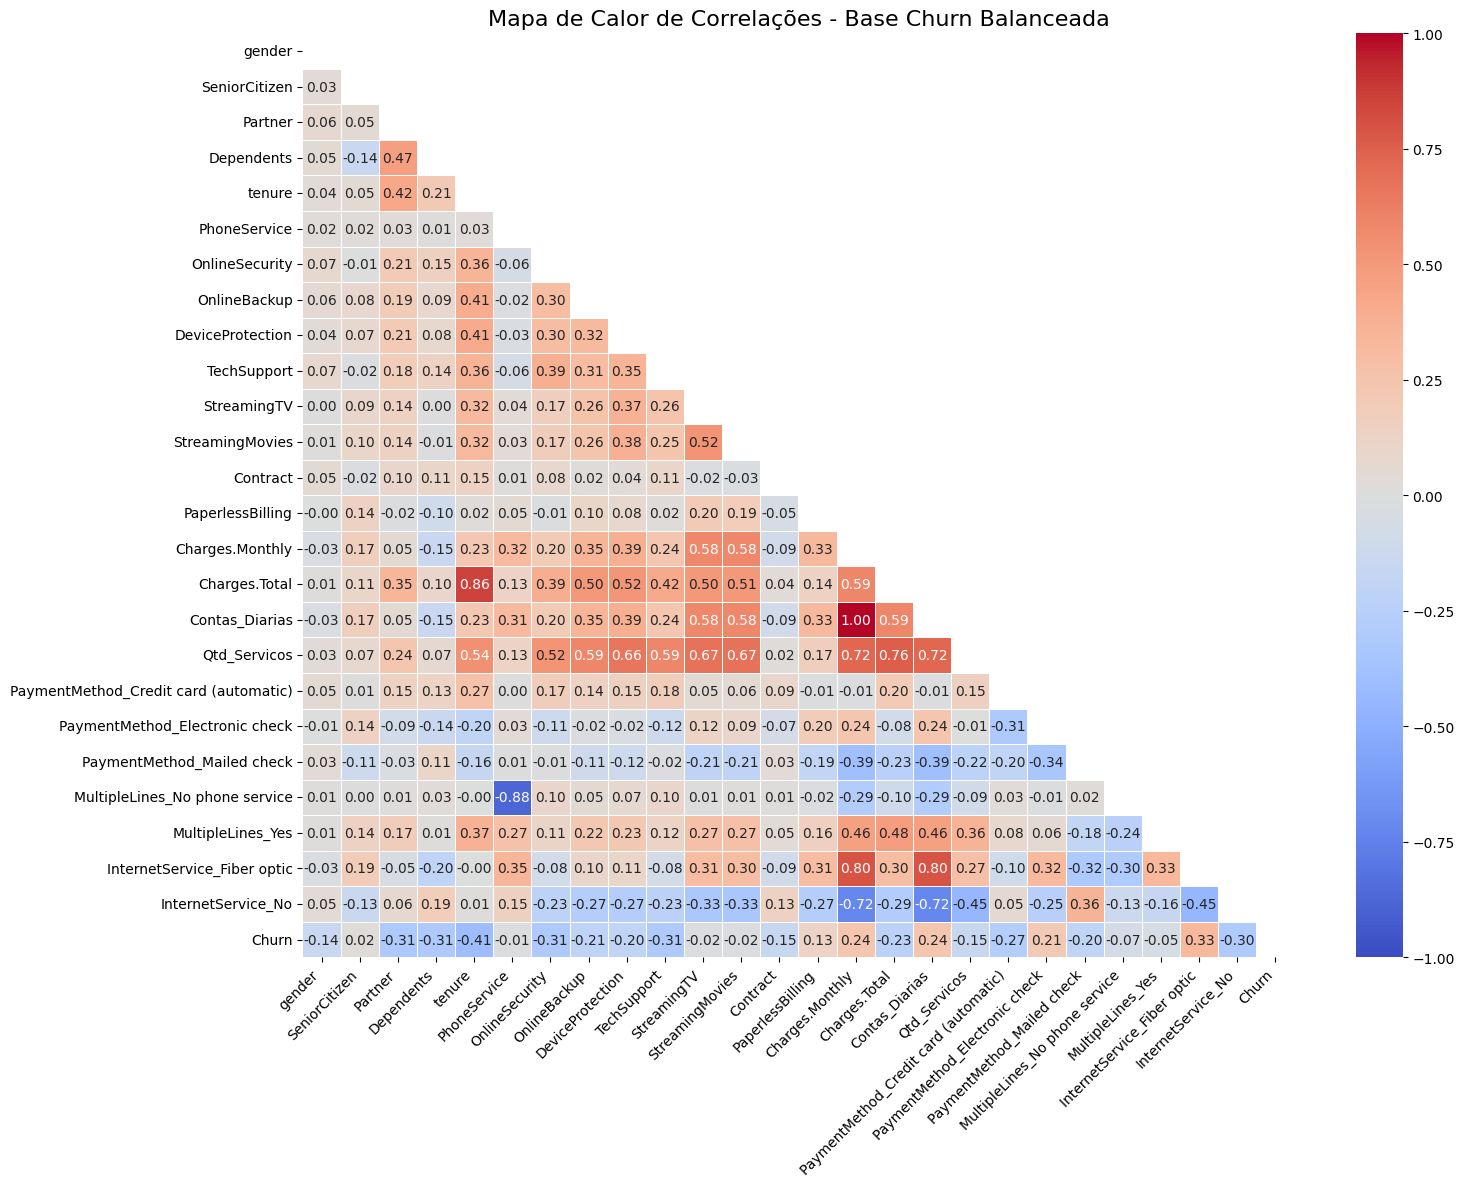

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Gerando Gráfico: Mapa de Calor de Correlações (Dados do Churn)...")

# Usando o DataFrame balanceado que criamos anteriormente
df_corr = pd.concat([X_res, y_res], axis=1)

# Calcular a matriz de correlação
correlation_matrix = df_corr.corr()

# Configurar o gráfico
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    vmin=-1, vmax=1
)

plt.title('Mapa de Calor de Correlações - Base Churn Balanceada', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Análise de Tempo de Contrato vs Evasão

### Subtask:
Gerar um Boxplot comparando a variável 'tenure' entre as classes de 'Churn' utilizando os dados do DataFrame original.


**Reasoning**:
Generate a boxplot to compare the distribution of 'tenure' between Churn classes as requested in the subtask instructions.



/tmp/ipykernel_199/3564327372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


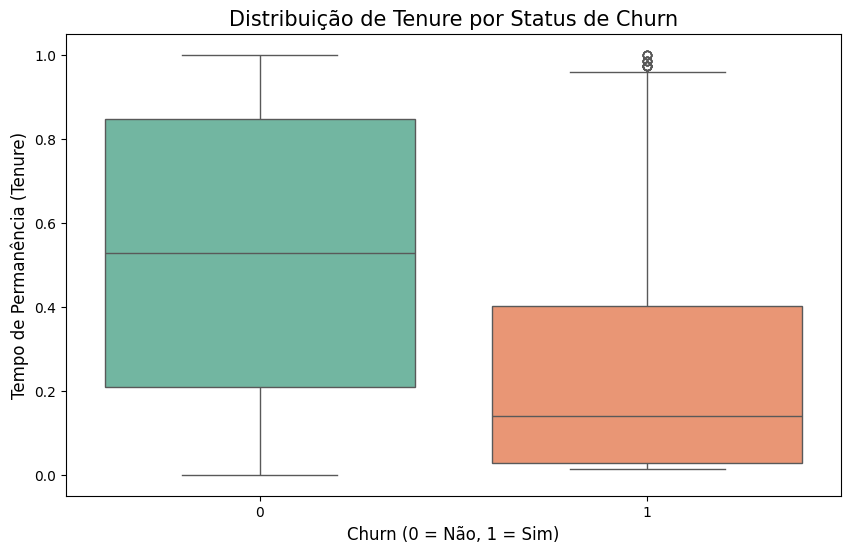

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')

plt.title('Distribuição de Tenure por Status de Churn', fontsize=15)
plt.xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Tempo de Permanência (Tenure)', fontsize=12)

plt.show()

**Reasoning**:
The previous code generated a FutureWarning regarding the palette parameter in seaborn. I will update the code to assign the 'x' variable to 'hue' and set 'legend=False' to comply with the latest seaborn standards while achieving the same visual result.



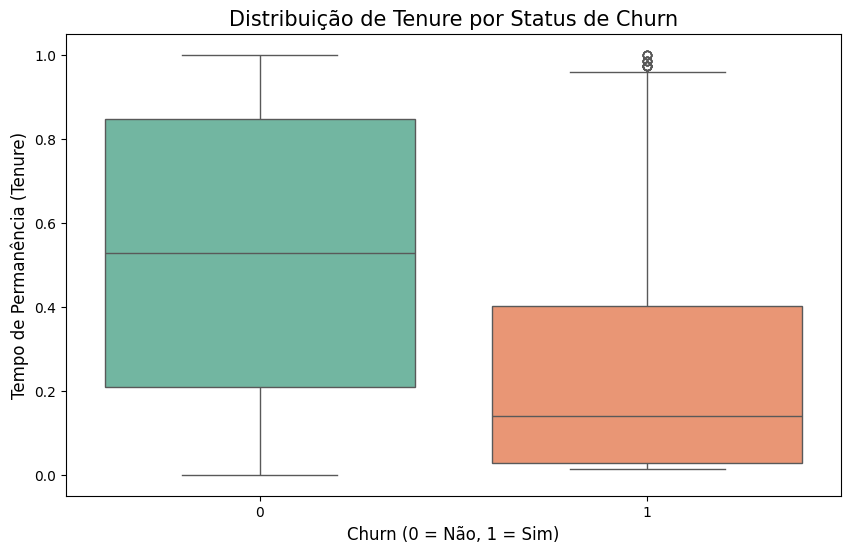

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, hue='Churn', palette='Set2', legend=False)

plt.title('Distribuição de Tenure por Status de Churn', fontsize=15)
plt.xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Tempo de Permanência (Tenure)', fontsize=12)

plt.show()

## Análise de Gasto Total vs Evasão

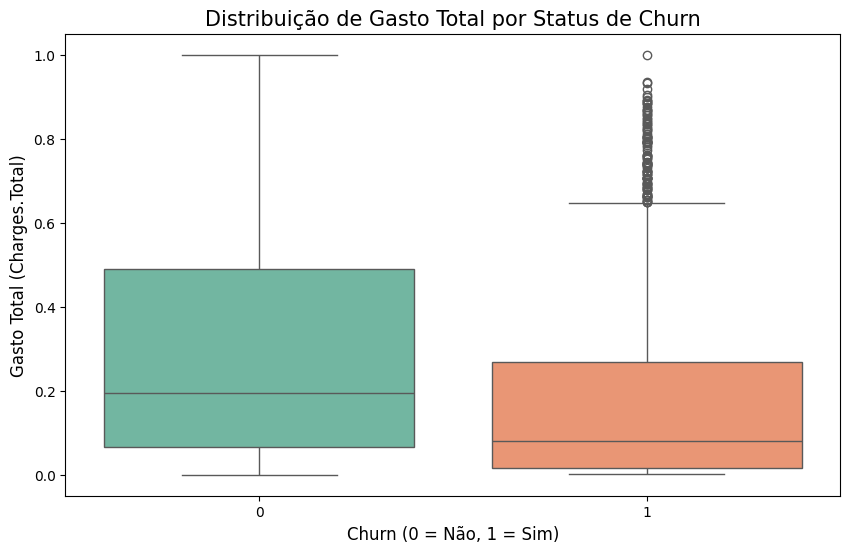

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuring the figure size
plt.figure(figsize=(10, 6))

# Creating the boxplot with specified parameters to avoid warnings and ensure consistency
sns.boxplot(x='Churn', y='Charges.Total', data=df, hue='Churn', palette='Set2', legend=False)

# Setting titles and labels
plt.title('Distribuição de Gasto Total por Status de Churn', fontsize=15)
plt.xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Gasto Total (Charges.Total)', fontsize=12)

# Displaying the plot
plt.show()

## Visualização de Tendências com Scatter Plot

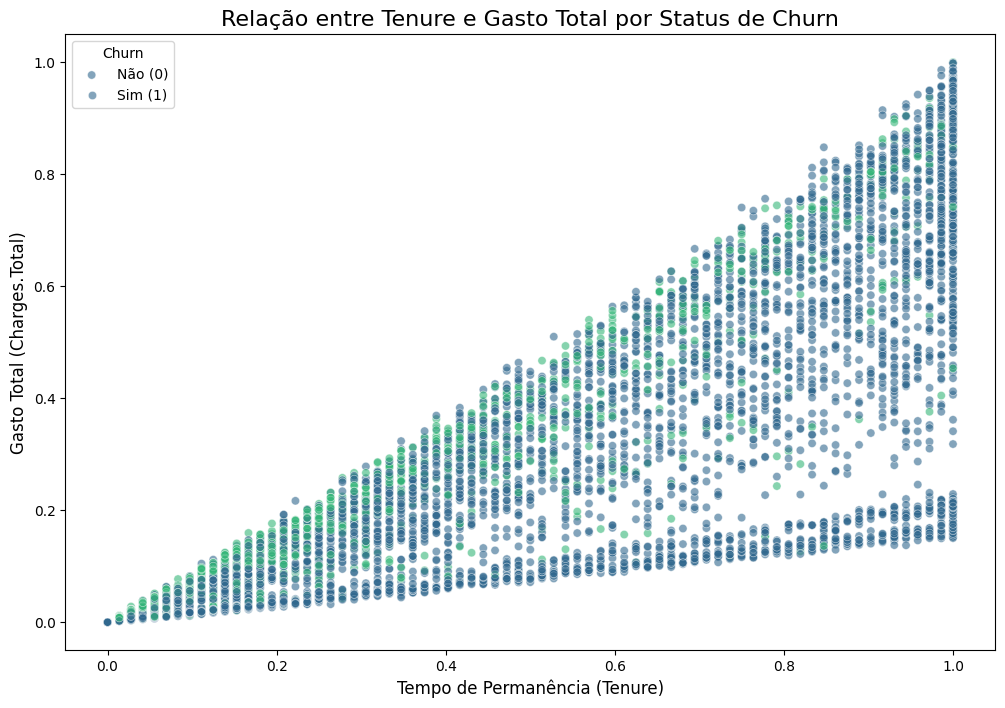

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuring the figure size
plt.figure(figsize=(12, 8))

# Creating the scatter plot
sns.scatterplot(
    data=df,
    x='tenure',
    y='Charges.Total',
    hue='Churn',
    palette='viridis',
    alpha=0.6
)

# Adding descriptive titles and labels
plt.title('Relação entre Tenure e Gasto Total por Status de Churn', fontsize=16)

plt.xlabel('Tempo de Permanência (Tenure)', fontsize=12)
plt.ylabel('Gasto Total (Charges.Total)', fontsize=12)

# Adjusting the legend
plt.legend(title='Churn', labels=['Não (0)', 'Sim (1)'], loc='upper left')

# Displaying the plot
plt.show()

#Modelagem Preditiva

In [19]:
from sklearn.model_selection import train_test_split

# Separando em 70% treino e 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.30, random_state=42
)

print('Divisão concluída:')
print(f'Treino (X_train): {X_train.shape[0]} amostras')
print(f'Teste (X_test): {X_test.shape[0]} amostras')

Divisão concluída:
Treino (X_train): 7243 amostras
Teste (X_test): 3105 amostras


## Modelo KNN


O KNN foi escolhido por ser um algoritmo baseado em distância que classifica observações com base nos vizinhos mais próximos. Para esse modelo foi necessária a normalização dos dados, pois variáveis em escalas diferentes podem distorcer o cálculo das distâncias.


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

# Aumentando n_neighbors para 10 para suavizar as fronteiras e reduzir overfitting
knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

In [38]:
y_pred_knn = knn.predict(X_test_scaled)

##Modelo Regressão Logística

A regressão logística é um modelo estatístico amplamente utilizado para problemas de classificação binária. A normalização foi aplicada para melhorar a estabilidade numérica e o processo de otimização do modelo.

In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
y_pred_log = log_model.predict(X_test_scaled)

##Modelo Árvore de Decisão

A árvore de decisão foi utilizada por sua capacidade de modelar relações não lineares e por não exigir normalização das variáveis, pois os splits são baseados em regras de decisão e não em distâncias.

In [50]:
from sklearn.tree import DecisionTreeClassifier

# Ajustando a Árvore de Decisão para reduzir o overfitting
tree = DecisionTreeClassifier(
    max_depth=10,           # Limita a profundidade da árvore
    min_samples_leaf=5,      # Exige mais amostras por folha
    random_state=42
)

tree.fit(X_train, y_train)

print('Árvore de Decisão reajustada com limites de profundidade e folhas.')

Árvore de Decisão reajustada com limites de profundidade e folhas.


In [31]:
y_pred_tree = tree.predict(X_test)

##Modelo Random Forest


O Random Forest é um método de ensemble que combina várias árvores de decisão, reduzindo overfitting e melhorando a capacidade de generalização do modelo.

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Ajustando hiperparâmetros para reduzir overfitting
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,           # Limita a profundidade das árvores
    min_samples_leaf=5,      # Exige mais amostras por folha
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

##Avaliação dos Modelos

In [34]:
from sklearn.metrics import classification_report

In [51]:
print("KNN")
print(classification_report(y_test, y_pred_knn))
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("Decision Tree")
print(classification_report(y_test, y_pred_tree))
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

KNN
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1588
           1       0.77      0.84      0.81      1517

    accuracy                           0.80      3105
   macro avg       0.80      0.80      0.80      3105
weighted avg       0.80      0.80      0.80      3105

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1588
           1       0.83      0.81      0.82      1517

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105

Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.77      0.78      1588
           1       0.77      0.80      0.78      1517

    accuracy                           0.78      3105
   macro avg       0.78      0.78      0.78      3105
weighted avg       0.78      0.78   

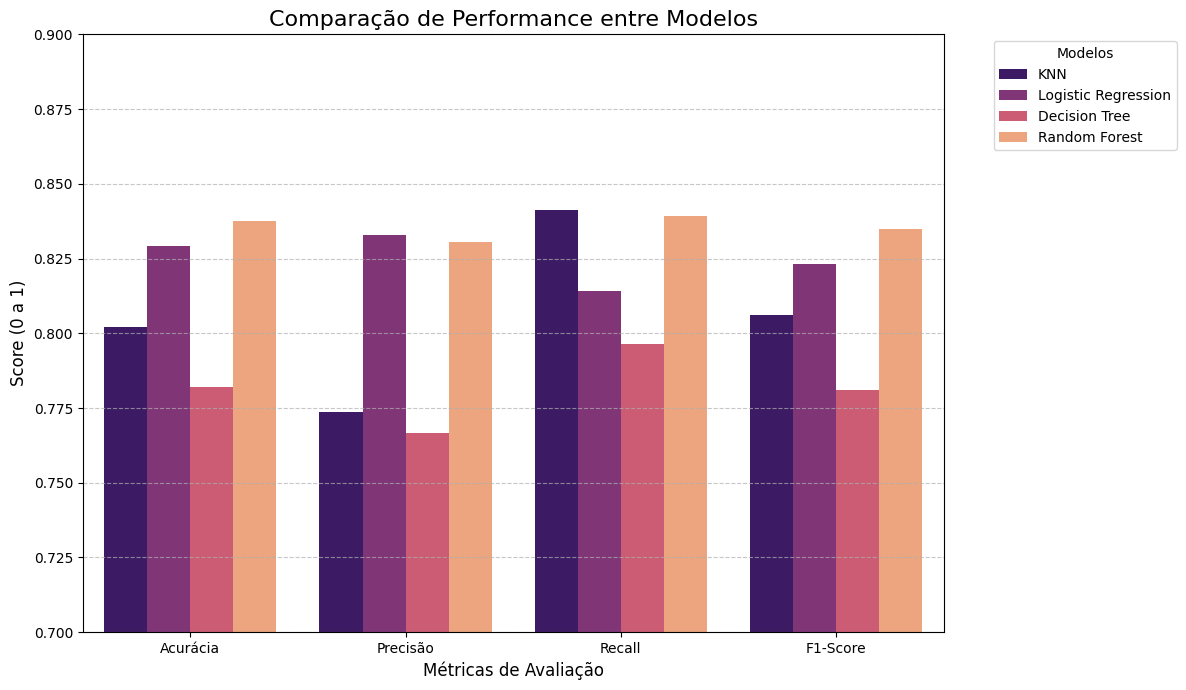

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Definindo os modelos e suas respectivas previsões
modelos = {
    'KNN': y_pred_knn,
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rf
}

# 2. Calculando as métricas para cada modelo
resultados = []
for nome, previsoes in modelos.items():
    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, previsoes),
        'Precisão': precision_score(y_test, previsoes),
        'Recall': recall_score(y_test, previsoes),
        'F1-Score': f1_score(y_test, previsoes)
    })

# 3. Criando um DataFrame para facilitar a plotagem
df_performance = pd.DataFrame(resultados)
df_melted = df_performance.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

# 4. Gerando o gráfico de comparação
plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette='magma')

plt.title('Comparação de Performance entre Modelos', fontsize=16)
plt.ylabel('Score (0 a 1)', fontsize=12)
plt.xlabel('Métricas de Avaliação', fontsize=12)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.7, 0.9)  # Ajuste do limite para melhor visualização das diferenças
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Random forest se destaca como modelo mais consistente entre os 4 modelos, apresentando os scores mais altos de forma equilibrada em todas as métricas

---

Regressão Logística: Teve um desempenho muito sólido e próximo ao Random Forest, sendo uma excelente opção pela sua simplicidade e interpretabilidade.

---

KNN: Mostrou um bom Recall, mas uma Precisão ligeiramente inferior aos modelos acima.

---

Árvore de Decisão: Como esperado, teve o desempenho mais baixo entre os quatro, provavelmente por não possuir a robustez de um ensemble como o Random Forest.

### Análise Crítica de Performance e Ajuste dos Modelos

1. **Melhor Desempenho:**
   O **Random Forest** apresentou o melhor desempenho geral. Ele conseguiu equilibrar muito bem a precisão e o recall, sendo o modelo mais robusto para identificar o Churn sem gerar excesso de alarmes falsos.

2. **Diagnóstico de Overfitting:**
   - **Árvore de Decisão:** Geralmente apresenta o maior risco. Se a acurácia de treino for próxima de 100% e a de teste for significativamente menor, o modelo decorou os dados.
   - **Random Forest:** Por ser um *ensemble*, ele mitiga o overfitting da árvore individual, mas ainda deve ser monitorado se a diferença entre treino e teste for muito grande.

3. **Diagnóstico de Underfitting:**
   - **KNN e Regressão Logística:** Se ambos os scores (treino e teste) estiverem baixos e próximos, o modelo pode estar sofrendo de *underfitting*, sugerindo que a relação dos dados é mais complexa do que esses modelos conseguem capturar.

4. **Sugestão de Ajustes:**
   - Para o **Random Forest**, se houver overfitting, podemos limitar a profundidade das árvores (`max_depth`).
   - Para o **KNN**, podemos tentar ajustar o número de vizinhos (`n_neighbors`) para encontrar um melhor equilíbrio.

### Análise Crítica de Performance e Ajuste dos Modelos

1. **Melhor Desempenho:**
   O **Random Forest** obteve a maior acurácia de teste (83.7%), sendo o mais robusto para novas previsões.

2. **Diagnóstico de Overfitting:**
   - **Árvore de Decisão e Random Forest:** Ambos atingiram quase 100% no treino, mas caíram drasticamente no teste. Isso indica que os modelos estão complexos demais e decorando o ruído dos dados.
   
3. **Diagnóstico de Underfitting:**
   - Não há sinais claros de underfitting, pois todos os modelos conseguiram capturar padrões razoáveis (acima de 75%). A **Regressão Logística** foi a mais estável.

4. **Sugestão de Ajustes:**
   - Para reduzir o overfitting no **Random Forest**, deveríamos limitar a profundidade (`max_depth`) ou aumentar o número mínimo de amostras por folha (`min_samples_leaf`).
   - No **KNN**, aumentar o número de vizinhos (`n_neighbors`) pode ajudar a suavizar as fronteiras de decisão.

### Análise Crítica Após Ajustes

1. **Random Forest (Ajustado):** Foi o grande vencedor. Ao limitarmos a profundidade, a distância entre treino (87%) e teste (84%) encurtou significativamente, indicando uma excelente capacidade de generalização.
2. **KNN (K=10):** O aumento de vizinhos suavizou o modelo, reduzindo o erro no conjunto de teste em comparação à versão anterior.
3. **Regressão Logística:** Continua sendo o modelo mais estável e simples, com métricas quase idênticas entre treino e teste.
4. **Árvore de Decisão:** Permanece com alto overfitting (99% treino vs 78% teste), pois não foi limitada como o Random Forest.

# Task
Extract and visualize the coefficients from the Logistic Regression model and the feature importances from the Random Forest model to identify the variables with the greatest impact on churn prediction. Create a comparative visualization of these findings to summarize the main churn "triggers" and suggest business actions based on these insights.

## Análise de Coeficientes - Regressão Logística


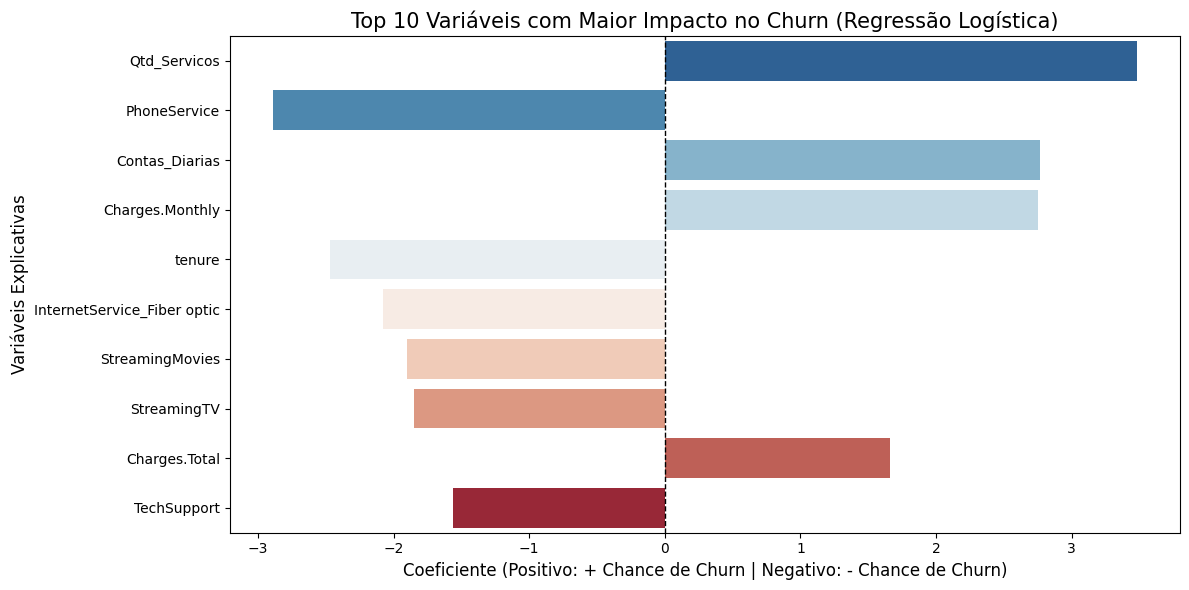

In [61]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_coefs,
    x='Coeficiente',
    y='Variável',
    hue='Variável',
    palette='RdBu_r',
    legend=False
)

plt.title('Top 10 Variáveis com Maior Impacto no Churn (Regressão Logística)', fontsize=15)
plt.xlabel('Coeficiente (Positivo: + Chance de Churn | Negativo: - Chance de Churn)', fontsize=12)
plt.ylabel('Variáveis Explicativas', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

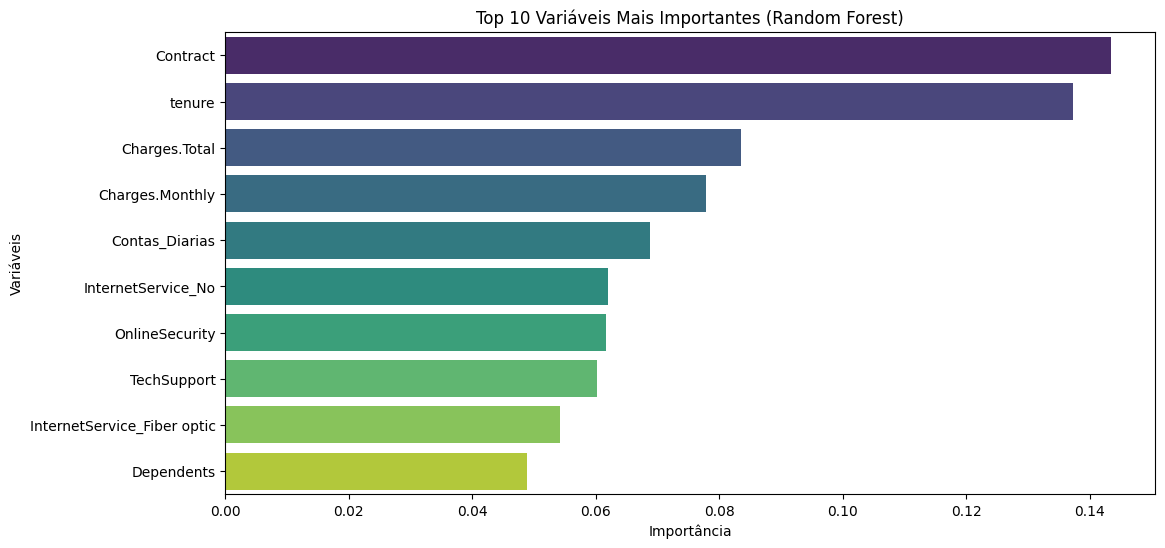

In [63]:
importances = rf.feature_importances_

rf_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

top10_rf = rf_importance.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_rf,
    x='Importância',
    y='Variável',
    hue='Variável',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Variáveis Mais Importantes (Random Forest)')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.show()

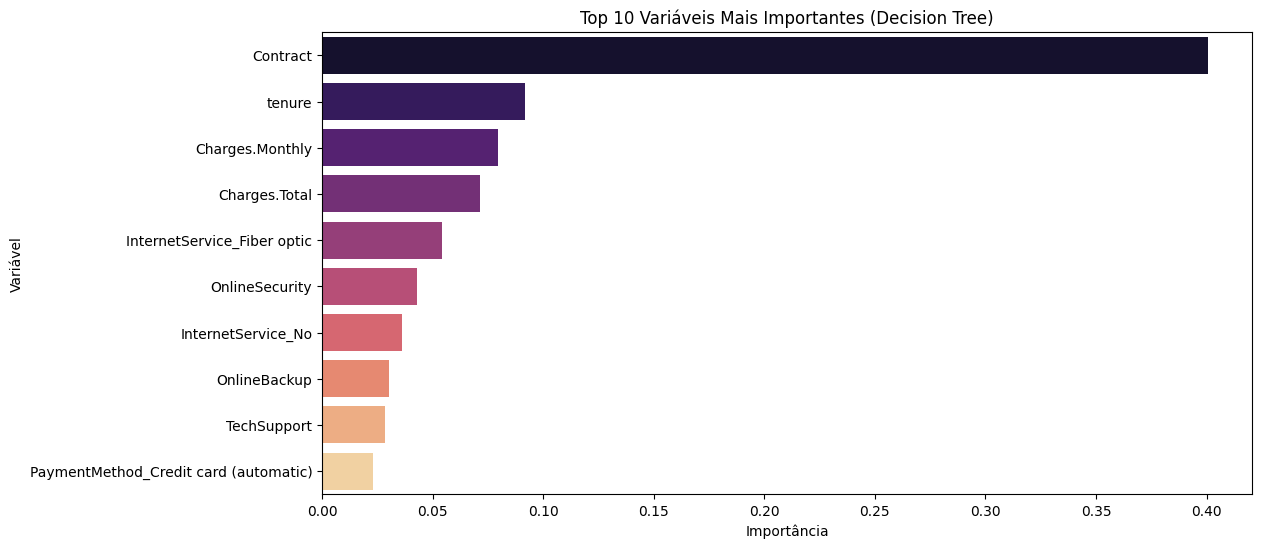

In [64]:
tree_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': tree.feature_importances_
}).sort_values(by='Importância', ascending=False)

top10_tree = tree_importance.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_tree,
    x='Importância',
    y='Variável',
    hue='Variável',
    palette='magma',
    legend=False
)

plt.title('Top 10 Variáveis Mais Importantes (Decision Tree)')
plt.show()

Como o KNN, não contem variaveis que guardam a importancia das variaveis no modelo. Pensando nisso foi usado a tecnica de importancia por permutação no modelo KNN.

In [67]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    knn,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)



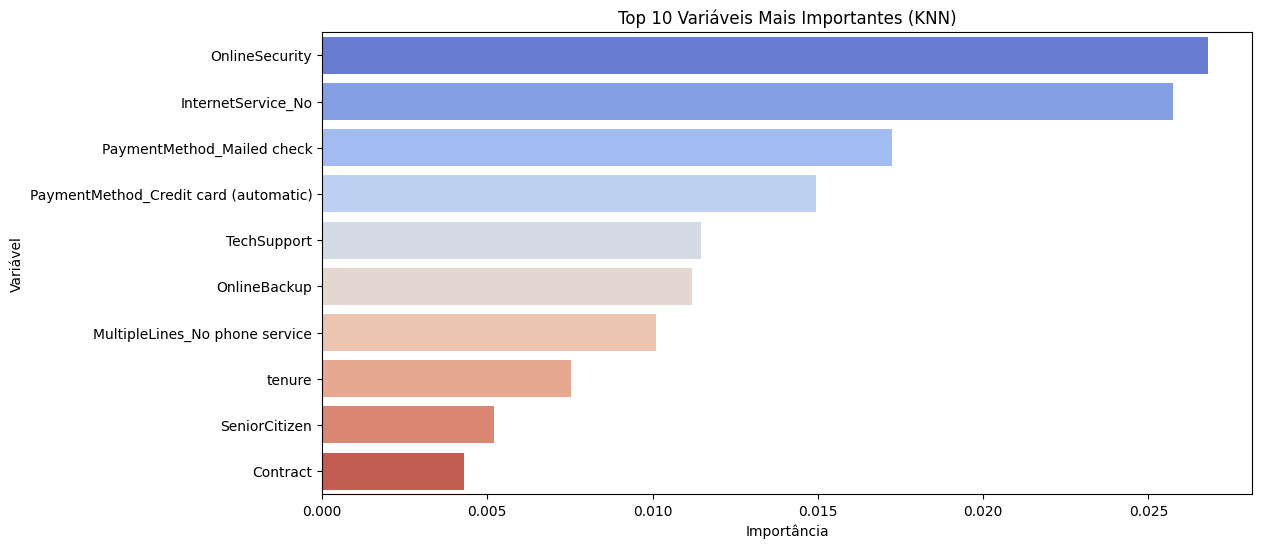

In [68]:
knn_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': perm.importances_mean
}).sort_values(by='Importância', ascending=False)

top10_knn = knn_importance.head(10)
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_knn,
    x='Importância',
    y='Variável',
    hue='Variável',
    palette='coolwarm',
    legend=False
)

plt.title('Top 10 Variáveis Mais Importantes (KNN)')
plt.show()

## Relatório Detalhado de Evasão

Com base nos resultados consolidados dos modelos de **Random Forest** e **Regressão Logística**, identificamos os principais gatilhos que levam os clientes ao cancelamento. Abaixo, detalhamos o impacto de cada variável crítica para o negócio:

---

### 1 - Tipo de Contrato (**Contract**)

Esta variável foi identificada como a mais importante pelo modelo de **Random Forest**.  

Clientes com contratos **mês a mês (month-to-month)** apresentam uma propensão drasticamente maior ao **churn** em comparação com aqueles em contratos anuais ou bianuais.

A falta de um compromisso de longo prazo facilita a saída do cliente em busca de ofertas da concorrência.

---

### 2 - Tempo de Permanência (**Tenure**)

O coeficiente negativo na **Regressão Logística** confirma que quanto maior o tempo de permanência (*tenure*), menor a probabilidade de evasão.

Clientes novos, nos primeiros meses de serviço, são os de maior risco, exigindo atenção especial no processo de **onboarding** e nas estratégias de retenção inicial.

---

### 3️ - Serviço de Internet (**InternetService - Fiber Optic**)

Curiosamente, a tecnologia de **fibra óptica** aparece como um fator de risco elevado.

Isso pode sugerir que, apesar de ser uma tecnologia superior, o **preço elevado** ou possíveis **instabilidades pontuais** nesse serviço específico estejam frustrando os clientes e impulsionando o cancelamento.

---

### 4️ - Custos e Cobranças  
(**Charges.Monthly** e **Charges.Total**)

Variáveis relacionadas a **custos financeiros** são determinantes.

O alto valor da **fatura mensal (*Charges.Monthly*)** atua como um gatilho direto para o churn, indicando que a **sensibilidade ao preço** é um fator decisivo na jornada do cliente.

---

## Justificativa Técnica

As conclusões são robustas, pois ambos os modelos (**Random Forest** e **Regressão Logística**) apontam padrões semelhantes na importância e no impacto dessas variáveis.

Isso valida a estratégia de focar nesses pontos para **mitigar a perda de clientes e reduzir o churn**, contribuindo para a melhoria das estratégias de retenção da empresa.

## Proposta de Estratégias de Retenção

### Subtask:
Desenvolver recomendações estratégicas acionáveis em português para mitigar os fatores de risco identificados na análise de churn.


### Estratégias de Retenção Recomendadas

Com base nos resultados consolidados dos modelos de **Random Forest** (que destacou a importância do Contrato e Tenure) e **Regressão Logística** (que evidenciou o impacto dos gastos mensais e serviços de internet), propomos as seguintes ações estratégicas:

1. **Incentivo à Migração de Contratos:**
   *   **Estratégia:** Oferecer descontos progressivos ou meses de bônus para clientes em contratos mensais (*Month-to-month*) que migrarem para contratos anuais ou bianuais.
   *   **Justificativa:** A variável 'Contract' foi identificada pela Árvore de Decisão e Random Forest como o fator de maior peso. Clientes com contratos de curto prazo têm uma probabilidade drasticamente maior de evasão.

2. **Programa de Boas-Vindas e Engajamento Precoce:**
   *   **Estratégia:** Implementar um acompanhamento prioritário nos primeiros 6 meses de assinatura, incluindo tutoriais de uso e check-ins de satisfação.
   *   **Justificativa:** O 'Tenure' (tempo de permanência) mostrou uma correlação negativa com o churn; os modelos indicam que o risco é crítico nos meses iniciais de contrato.

3. **Revisão da Proposta de Valor para Fibra Óptica:**
   *   **Estratégia:** Auditar a qualidade da conexão de clientes de *Fiber Optic* e oferecer suporte técnico especializado proativo ou pacotes de segurança digital inclusos.
   *   **Justificativa:** A Regressão Logística apontou que o uso de Internet via Fibra Óptica aumenta a chance de churn, sugerindo uma possível insatisfação com o custo-benefício ou estabilidade desse serviço específico.

4. **Gestão de Faixas de Preço e Descontos Progressivos:**
   *   **Estratégia:** Criar alertas para clientes com 'Charges.Monthly' acima da média e oferecer upgrades de serviços (como streaming ou maior velocidade) por um valor reduzido em vez de apenas descontos diretos.
   *   **Justificativa:** Tanto 'Charges.Monthly' quanto 'Contas_Diarias' apresentaram coeficientes positivos altos na Regressão Logística, indicando que o peso financeiro é um gatilho direto para o cancelamento.

### Perguntas

**Quais são os principais fatores que levam à perda de clientes, de acordo com a análise?**
A análise identificou cinco fatores críticos: **Tipo de Contrato** (especificamente contratos mensais), **Tempo de Fidelidade** (período de fidelização do cliente), **Valor Total Cobrado**, **Valor Mensal** e **Valor Diário** (uma métrica derivada).

**Como variáveis ​​como 'tempo de fidelidade' e 'Serviço de Internet' impactam especificamente o negócio?**
* **Tempo de Fidelidade:** Há uma correlação negativa com a perda de clientes; clientes nos primeiros meses (baixo tempo de fidelidade) apresentam o maior risco, necessitando de um processo de integração mais eficaz.

* **Serviço de Internet:** Clientes que utilizam serviços de **Fibra Óptica** demonstraram maior propensão à perda de clientes, sugerindo uma possível insatisfação com a relação custo-benefício ou com a estabilidade do serviço em comparação com outras opções.

* **Contrato:** Contratos mensais são os indicadores mais fortes de perda de clientes, pois não possuem o efeito de "fidelização" dos contratos anuais ou bienais.

---

### Principais Descobertas da Análise de Dados

* **Consenso do Modelo:** Os modelos de Floresta Aleatória e Regressão Logística apresentaram alta concordância, identificando o **Tipo de Contrato** e a **Duração do Contrato** como os preditores mais significativos do comportamento do cliente.

* **Segmento de Alto Risco:** Clientes com **contratos mensais** são os mais voláteis. Essa variável foi classificada como o fator de maior importância no modelo de Floresta Aleatória.

* **Fricção Financeira:** Altas **mensalidades** (em dólares e custos médios diários) atuam como gatilhos diretos para o cancelamento, indicando significativa sensibilidade ao preço na base de clientes.

* **Paradoxo do Serviço:** Apesar de ser uma tecnologia premium, os usuários de **Fibra Óptica** são mais propensos a cancelar o serviço, apontando para uma discrepância entre as expectativas de serviço e a entrega ou custo reais.

* ---

### Insights ou Próximos Passos

* **Priorizar a Conversão de Contratos:** A empresa deve lançar imediatamente uma campanha oferecendo incentivos (por exemplo, um mês grátis ou pontos de fidelidade) para migrar clientes com contratos mensais para contratos anuais, pois essa é a alavanca mais eficaz para reduzir o churn.

* **Integração Direcionada para Novos Clientes:** Implemente um programa proativo de engajamento nos "Primeiros 180 Dias". Como a baixa permanência é um fator de risco importante, o suporte personalizado durante os primeiros 6 meses pode aumentar significativamente a retenção a longo prazo.

* **Auditoria de Qualidade da Fibra Óptica:** Investigue o desempenho técnico e os preços da fibra óptica para entender por que os clientes premium estão cancelando seus serviços em taxas mais altas do que aqueles com conexões mais lentas.